# **Importing Dataset**

In [20]:
#Authorises the notebook to gain access to files within our google drive allowing it to access our RTA Dataset.csv.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
!cd /content/drive/MyDrive/Machine learning project
# The !cd command will open the directory with the dataset path.

/bin/bash: line 1: cd: too many arguments


In [22]:
import pandas as pd
# Imports Pandas as pd.

In [23]:
Dataset = pd.read_csv("/content/drive/MyDrive/Machine learning project/Dataset/RTA Dataset.csv")
# Reads the csv file of our datset and assigns it to the variable Dataset.
Dataset.head(5)
#Reads the first 5 rows of the datset to confirm the file can be read.

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


# Data Visualisation

**Prior to preprocessing the data The following code was used to see how many missing columns have data and the percentage of those columns that are missing.**


In [5]:
missing = Dataset.isnull().sum()
# Checks to see the amount of missing values in each column and sums it up.
missing_percentage = (missing/len(Dataset)) * 100
# Shows the number of missing values as a percentage.
print(missing[missing > 0])
#Prints the sum of missing values in columns that only have missing values for better visualisation.
print(missing_percentage[missing_percentage > 0])
# Prints only the missing columns and percentage that are missing.

Educational_level           741
Vehicle_driver_relation     579
Driving_experience          829
Type_of_vehicle             950
Owner_of_vehicle            482
Service_year_of_vehicle    3928
Defect_of_vehicle          4427
Area_accident_occured       239
Lanes_or_Medians            385
Road_allignment             142
Types_of_Junction           887
Road_surface_type           172
Type_of_collision           155
Vehicle_movement            308
Work_of_casuality          3198
Fitness_of_casuality       2635
dtype: int64
Educational_level           6.016564
Vehicle_driver_relation     4.701202
Driving_experience          6.731082
Type_of_vehicle             7.713543
Owner_of_vehicle            3.913608
Service_year_of_vehicle    31.893472
Defect_of_vehicle          35.945112
Area_accident_occured       1.940565
Lanes_or_Medians            3.126015
Road_allignment             1.152972
Types_of_Junction           7.202014
Road_surface_type           1.396557
Type_of_collision           1.2

# A heatmap to visualise missing values

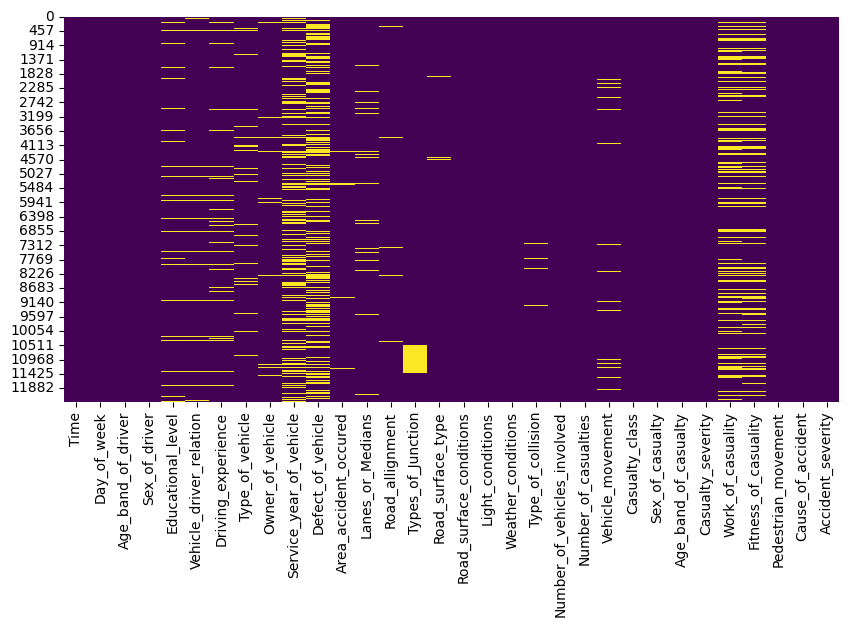

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(Dataset.isnull(), cbar=False, cmap="viridis")
plt.show()

# Data Preprocessing

**This stage will begin altering the data to make data more suitable for training, testing and optimising for our target problem.**

In [49]:

# Created a new variable DF data frame wwhich will be the data used for this model in regards to training and testing.
Df = Dataset.drop(["Work_of_casuality"], axis=1)
# Work_of_casuality was dropped due to high amounts of missing values and low correlation with the target problem.

Df["Defect_of_vehicle"] = Df["Defect_of_vehicle"].fillna("Unknown")
Df["Fitness_of_casuality"] = Df["Fitness_of_casuality"].fillna("Unknown")
Df["Service_year_of_vehicle"] = Df["Service_year_of_vehicle"].fillna("Unknown")
Df["Driving_experience"] = Df["Driving_experience"].fillna("Unknown")
Df["Owner_of_vehicle"] = Df["Owner_of_vehicle"].fillna("Unknown")
Df["Area_accident_occured"] = Df["Area_accident_occured"].fillna("Unknown")
# Fills all missing values in these columns as unknown.


Categorical_values = ["Educational_level", "Vehicle_driver_relation",
                      "Type_of_vehicle", "Lanes_or_Medians", "Road_allignment",
                      "Types_of_Junction", "Road_surface_type", "Type_of_collision",
                      "Vehicle_movement"]


for cat in Categorical_values:
  Df[cat] = Df[cat].fillna(Df[cat].mode()[0])
# Fills all missing values in the Categorical_values with the mode.

missing = Df.isnull().sum()
missing_percentage = (missing/len(Df)) * 100
print(missing[missing > 0])
print(missing_percentage[missing_percentage > 0])

# prints the columns agin to show no more missing values.



Series([], dtype: int64)
Series([], dtype: float64)


In [50]:
print(Df.columns.tolist())

['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


Encoding columns to prepare for training and testing.

In [51]:
Df['Hour'] = pd.to_datetime(Df['Time'], format='%H:%M:%S').dt.hour
#Creates a new column "Hour"  and changes the format into a datetime object that pandas can work with
Df = Df.drop(columns=['Time'])
#Drops the time column.

In [52]:
from sklearn.preprocessing import LabelEncoder
#Import the label encoder from the sklearn.preprocessing library.



ordinal_cols = ["Educational_level", "Driving_experience", "Service_year_of_vehicle",
                "Age_band_of_driver", "Age_band_of_casualty", "Casualty_severity", "Fitness_of_casuality"]

# Make a list of all the ordinal columns to be encoded.

le = LabelEncoder()
#Defines LableEncoder as le.

for col in ordinal_cols:
    Df[col] = le.fit_transform(Df[col])
#Uses a for loop to transform these columns using label encoding.



nominal_cols = ["Day_of_week", "Sex_of_driver", "Vehicle_driver_relation",
                "Type_of_vehicle", "Owner_of_vehicle", "Defect_of_vehicle",
                "Area_accident_occured", "Lanes_or_Medians", "Road_allignment",
                "Types_of_Junction", "Road_surface_type", "Road_surface_conditions",
                "Light_conditions", "Weather_conditions", "Type_of_collision",
                "Vehicle_movement", "Casualty_class", "Sex_of_casualty", "Pedestrian_movement", "Cause_of_accident"]
existing_cols = [col for col in nominal_cols if col in Df.columns]
#Creates a lits of all nominal columns for one hot encoding.


Df = pd.get_dummies(Df, columns=existing_cols, drop_first=True)
# Converts categorical variables into binary numeric columns


target_le = LabelEncoder()
#Creates a sepearte label encoder for the target values.

y = target_le.fit_transform(Df['Accident_severity'])
#Sets y to encode the accident severity column as that is the classification for the target problem.
X = Df.drop('Accident_severity', axis=1)
#Assigns X as all columns except for accident severity.


In [53]:
from sklearn.model_selection import train_test_split
#Imports the train_test_split from the sklearn.model_selection library.

X_train, X_test, y_train, y_test = train_test_split(
    #creates the variables for the data to be sepearted into for training and testing.,
    X, y, test_size=0.2, random_state=42, stratify=y
    # x, y Represents the input features and target variable.
    # Assigns 20% of the data for testing while assigning the 80% for training.
    # Assigns a seed value ensuring that the same rows will be selected for training and testing each time the code is run.
    # The proportion of classes (e.g., fatal, serious, slight injury) remains consistent between the training and test sets.
)

# Model Implementation

In [54]:
from xgboost import XGBClassifier
# import the XGBClassifier from the xgboost library.
import numpy as np
#Import Numpy library as np.

num_classes = len(np.unique(y))
# Set num_classes to be the length of unique classes. This will return the number of unique classes.

model = XGBClassifier(
    objective='multi:softprob',
    #creates a objective and assigns it to tell XGBoost that this is a multi-class classification task.
    num_class=len(target_le.classes_),
    #tells the model how many distinct output categories there are.
    eval_metric='mlogloss',
    #evaluation metric used to measure performance during training.
    random_state=42
    #every time you run your code, the random splits and initializations will be identical
)

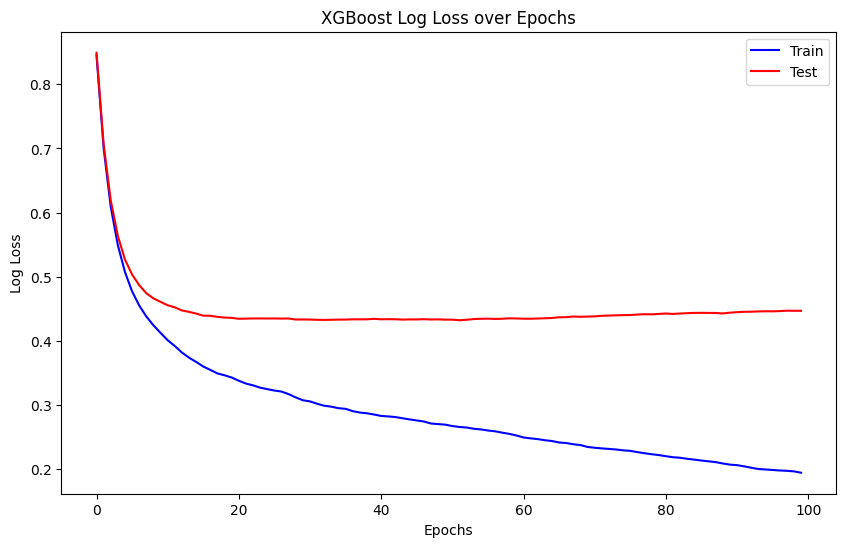

Final Training Log Loss: 0.1941
Final Test Log Loss: 0.4467
Test Accuracy: 0.8551
Weighted F1-Score: 0.8048


In [55]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, log_loss
# Imports accuracy_score, f1_score, classification_report, log_loss from the skleanr.metrics library.

model.fit(
    X_train, y_train,
    # Evaluates performance on both training and test sets during training.
    eval_set=[(X_train, y_train), (X_test, y_test)],
    # Disable verbose output to prevent printing progress for each iteration
    verbose=False
)

evals_result = model.evals_result()


epochs = len(evals_result['validation_0']['mlogloss'])
#number of training epochs completed
x_axis = range(epochs)
#Create a range of epoch values for the x-axis of the plot

#Plots the graph as a duel line graph.
plt.figure(figsize=(10,6))
plt.plot(x_axis, evals_result['validation_0']['mlogloss'], label='Train', color ='blue')
plt.plot(x_axis, evals_result['validation_1']['mlogloss'], label='Test', color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss over Epochs')
plt.legend()
plt.show()

#preicts the accuracy of the model in classifying into correct classes.
y_pred = model.predict(X_test)

#Extract the final log loss value for the training data.
train_logloss = evals_result['validation_0']['mlogloss'][-1]
#Extract the final log loss value for the Testing data
test_logloss = evals_result['validation_1']['mlogloss'][-1]
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

#Prints the accuracy scores.
print(f"Final Training Log Loss: {train_logloss:.4f}")
print(f"Final Test Log Loss: {test_logloss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


In [56]:
from sklearn.metrics import classification_report

#Prints classification report.
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_le.classes_ ))


Classification Report:
                precision    recall  f1-score   support

  Fatal injury       1.00      0.10      0.18        31
Serious Injury       0.69      0.09      0.17       349
 Slight Injury       0.86      0.99      0.92      2084

      accuracy                           0.86      2464
     macro avg       0.85      0.40      0.42      2464
  weighted avg       0.84      0.86      0.80      2464



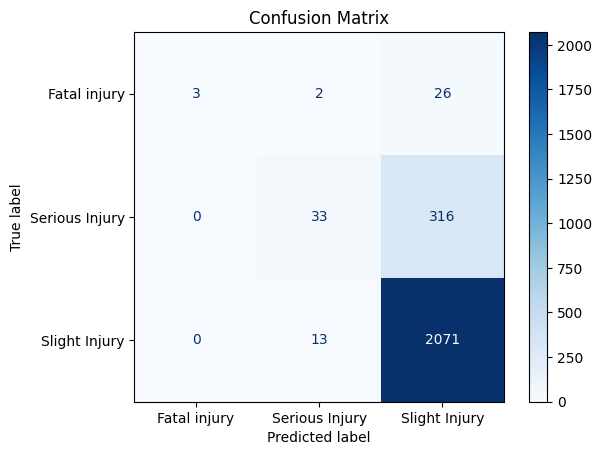

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

#Displays confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_le.classes_)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()